이상 데이터 추출

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_test = pd.read_csv('test_features.csv')
df_train = pd.read_csv('train_features.csv')
df_valid = pd.read_csv('valid_features.csv')

In [3]:
#3개의 df 각각 전처리

feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

# 1. inf 값을 NaN으로 바꾸기
df_test = df_test.replace([np.inf, -np.inf], np.nan)
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_valid = df_valid.replace([np.inf, -np.inf], np.nan)

# 2. feature 컬럼 기준 결측치 제거
df_test = df_test.dropna(subset=feature_cols).copy()
df_train = df_train.dropna(subset=feature_cols).copy()
df_valid = df_valid.dropna(subset=feature_cols).copy()

# 3. 너무 큰 값 잘라내기: 극단값 완화
for col in feature_cols:
    lower = df_test[col].quantile(0.01)
    upper = df_test[col].quantile(0.99)
    df_test[col] = df_test[col].clip(lower, upper)
    lower = df_train[col].quantile(0.01)
    upper = df_train[col].quantile(0.99)
    df_train[col] = df_train[col].clip(lower, upper)
    lower = df_valid[col].quantile(0.01)
    upper = df_valid[col].quantile(0.99)
    df_valid[col] = df_valid[col].clip(lower, upper)

# 4. X 생성
X_test = df_test[feature_cols].copy()
X_train = df_train[feature_cols].copy()
X_valid = df_valid[feature_cols].copy()
print("test dataset 전처리 완료 및 크기")
print(X_test.isna().sum())
print(np.isinf(X_test).sum())
print(X_test.shape)
print("train dataset 전처리 완료 및 크기")
print(X_train.isna().sum())
print(np.isinf(X_train).sum())
print(X_train.shape)
print("validation dataset 전처리 완료 및 크기")
print(X_valid.isna().sum())
print(np.isinf(X_valid).sum())
print(X_valid.shape)

test dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
(3698, 8)
train dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtyp

In [11]:
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()
df_valid_scaled = df_valid.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_train[feature_cols])
df_train_scaled[feature_cols] = scaler.transform(df_train[feature_cols])
df_test_scaled[feature_cols] = scaler.transform(df_test[feature_cols])
df_valid_scaled[feature_cols] = scaler.transform(df_valid[feature_cols])

X_test_scaled = df_test_scaled[feature_cols].copy()
X_train_scaled = df_train_scaled[feature_cols].copy()
X_valid_scaled = df_valid_scaled[feature_cols].copy()

X_train_scaled.head()

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,-0.144590,-0.655294,-0.019492,-0.882692,-0.586969,-1.240012,0.375525,0.534481
1,0.233756,-0.336517,-0.200084,-1.031000,-0.480942,-0.615611,-0.357393,0.534481
2,1.392300,1.134687,-1.198665,-0.604246,0.157921,-0.779927,0.210512,0.534481
3,-0.646832,0.108484,0.728194,-0.323677,-0.422249,-0.754366,0.502202,-0.424950
4,-1.036270,-1.181900,0.530983,-0.220504,-0.796057,-0.693661,-0.052010,-1.384381


In [17]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
iso_model.fit(X_train_scaled)

#이상치 점수
df_train_scaled["anomaly_score"] = -iso_model.decision_function(X_train_scaled)
df_test_scaled["anomaly_score"] = -iso_model.decision_function(X_test_scaled)
df_valid_scaled["anomaly_score"] = -iso_model.decision_function(X_valid_scaled)
#label명 바꾸기 (정상:1, 이상치:-1) => (정상:0, 이상치:1)
df_train_scaled["anomaly_label"] = iso_model.predict(X_train_scaled)
df_train_scaled["anomaly_label"] = df_train_scaled["anomaly_label"].map({1: 0, -1: 1})
df_test_scaled["anomaly_label"] = iso_model.predict(X_test_scaled)
df_test_scaled["anomaly_label"] = df_test_scaled["anomaly_label"].map({1: 0, -1: 1})
df_valid_scaled["anomaly_label"] = iso_model.predict(X_valid_scaled)
df_valid_scaled["anomaly_label"] = df_valid_scaled["anomaly_label"].map({1: 0, -1: 1})

#정상 데이터와 이상 데이터 개수 표시
df_train_scaled["anomaly_label"].value_counts()

anomaly_label
0    41047
1     1270
Name: count, dtype: int64

In [13]:
df_train_scaled.head()

,date,adj_close,close,high,low,open,volume,ticker,group,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d,anomaly_score,anomaly_label
0,2024-01-09,21399.152344,22150.0,22350.0,22100.0,22350.0,90774.0,000080.KS,Medium,-0.144590,-0.655294,-0.019492,-0.882692,-0.586969,-1.240012,0.375525,0.534481,-0.211921,0
1,2024-01-10,21302.542969,22050.0,22200.0,21850.0,22150.0,129971.0,000080.KS,Medium,0.233756,-0.336517,-0.200084,-1.031000,-0.480942,-0.615611,-0.357393,0.534481,-0.218972,0
2,2024-01-11,20674.576172,21400.0,22150.0,21200.0,22050.0,330021.0,000080.KS,Medium,1.392300,1.134687,-1.198665,-0.604246,0.157921,-0.779927,0.210512,0.534481,-0.154985,0
3,2024-01-12,21061.017578,21800.0,21850.0,21400.0,21400.0,194748.0,000080.KS,Medium,-0.646832,0.108484,0.728194,-0.323677,-0.422249,-0.754366,0.502202,-0.424950,-0.218104,0
4,2024-01-15,21350.847656,22100.0,22150.0,21750.0,21900.0,24583.0,000080.KS,Medium,-1.036270,-1.181900,0.530983,-0.220504,-0.796057,-0.693661,-0.052010,-1.384381,-0.178792,0


In [14]:
#이상치 점수가 가장 높은 30개의 데이터 확인
top_anomaly = (
    df_train_scaled
    .sort_values("anomaly_score", ascending=False)
    .head(30)
)

top_anomaly[[
    "date",
    "ticker",
    "anomaly_score",
    "vol_chg_rate",
    "volume_ma20_ratio",
    "volatility_5d",
    "upper_shadow_ratio"
]]

,date,ticker,anomaly_score,vol_chg_rate,volume_ma20_ratio,volatility_5d,upper_shadow_ratio
18377,2024-09-25,021040.KQ,0.144130,5.026512,5.548866,4.402006,2.584445
18521,2025-04-30,021040.KQ,0.131256,6.052303,5.548866,4.402006,2.438391
34098,2025-09-12,060230.KQ,0.129489,6.052303,5.548866,3.806809,2.297793
33550,2025-03-21,058450.KQ,0.126341,6.052303,5.548866,4.402006,-1.240012
37721,2025-09-01,083660.KQ,0.126259,6.052303,5.548866,4.402006,-1.190230
33968,2025-03-06,060230.KQ,0.123465,6.052303,5.548866,4.402006,-1.087984
37715,2025-08-22,083660.KQ,0.120749,6.052303,5.548866,4.402006,-0.217857
37754,2025-10-23,083660.KQ,0.118504,6.052303,5.548866,4.033392,-0.137808
18525,2025-05-09,021040.KQ,0.118094,6.052303,5.548866,4.402006,-1.240012
33434,2024-09-25,058450.KQ,0.117759,5.516281,5.548866,4.402006,-0.163146


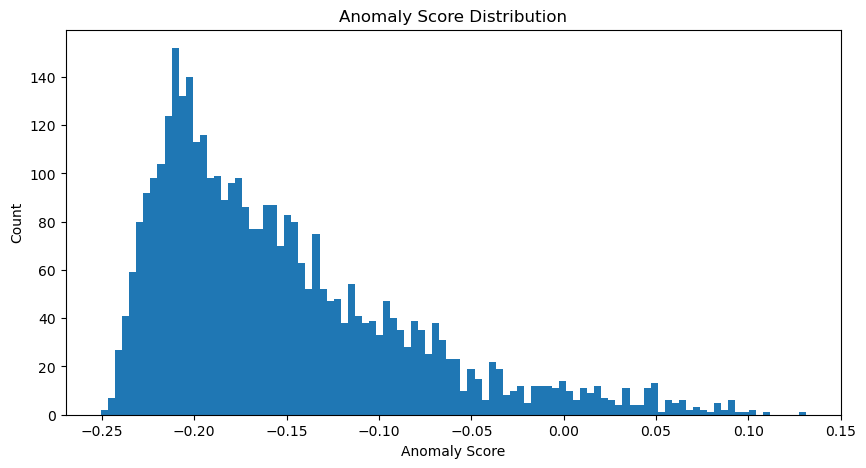

In [42]:
#이상치 점수 분포 확인
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_test_scaled["anomaly_score"], bins=100)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.savefig('Anomaly Score Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

이상 데이터 분리 후 클러스터링

In [21]:
#이상 데이터만 따로 분류
anomaly_train_df = df_train_scaled[
    df_train_scaled["anomaly_label"] == 1
].copy()

anomaly_test_df = df_test_scaled[
    df_test_scaled["anomaly_label"] == 1
].copy()

anomaly_valid_df = df_valid_scaled[
    df_valid_scaled["anomaly_label"] == 1
].copy()

In [23]:
#클러스터링에 사용할 feature들

cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_train_cluster = anomaly_train_df[cluster_feature_cols].copy()
X_test_cluster = anomaly_test_df[cluster_feature_cols].copy()
X_valid_cluster = anomaly_valid_df[cluster_feature_cols].copy()

#클러스터링 전 전처리: 무한대 값 및 결측치 포함된 행 제거
X_train_cluster = X_train_cluster.replace([np.inf, -np.inf], np.nan)
X_train_cluster = X_train_cluster.dropna()
X_test_cluster = X_test_cluster.replace([np.inf, -np.inf], np.nan)
X_test_cluster = X_test_cluster.dropna()
X_valid_cluster = X_valid_cluster.replace([np.inf, -np.inf], np.nan)
X_valid_cluster = X_valid_cluster.dropna()

# anomaly_df도 X_cluster 인덱스에 맞추기
anomaly_train_df = anomaly_train_df.loc[X_train_cluster.index].copy()
anomaly_test_df = anomaly_test_df.loc[X_test_cluster.index].copy()
anomaly_valid_df = anomaly_valid_df.loc[X_valid_cluster.index].copy()

print(X_train_cluster.shape)

(1270, 8)


C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

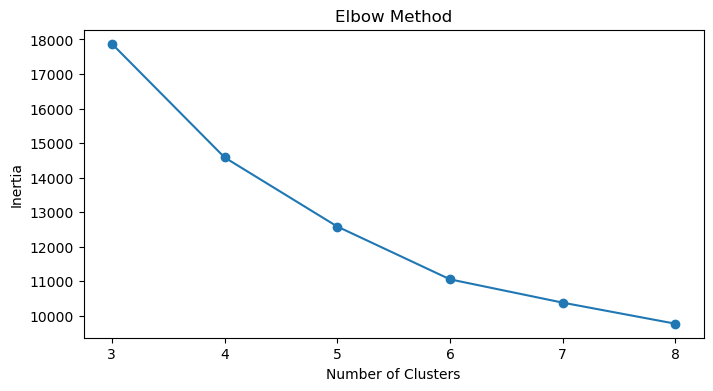

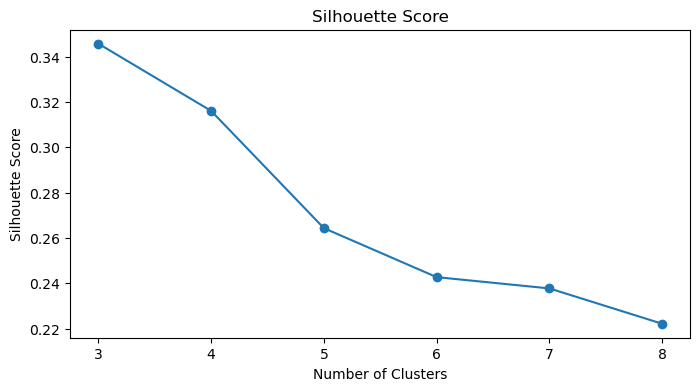

,k,inertia,silhouette
0,3,17877.649230,0.345650
1,4,14584.515989,0.316010
2,5,12582.676986,0.264299
3,6,11053.212092,0.242694
4,7,10378.195522,0.237726
5,8,9767.895654,0.222148


In [32]:
#K-Means 수행 전 K 설정 위한 inertia, silhouette score 확인
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(3, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_cluster)
    labels = kmeans.predict(X_valid_cluster)

    inertias.append(kmeans.inertia_)


    silhouette_scores.append(silhouette_score(X_valid_cluster, labels))


plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig('Elbow Method.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.savefig('Silhouette .png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [33]:
#k=4으로 설정 후 K-Means 진행

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train_cluster)
anomaly_test_df["cluster"] = kmeans.fit_predict(X_test_cluster)

anomaly_test_df["cluster"].value_counts().sort_index()

C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


cluster
0    67
1    28
2    28
3    36
Name: count, dtype: int64

In [34]:
#클러스터 별 feature 평균값 확인
cluster_profile = (
    anomaly_test_df
    .groupby("cluster")[cluster_feature_cols]
    .mean()
)

cluster_profile

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,-0.116038,0.632633,-2.356011,5.472157,4.493033,-0.209995,0.056920,0.090565
1,2.626982,3.668969,1.036879,1.757510,2.170436,1.351019,-0.245609,0.808604
2,1.013037,1.623422,5.500070,5.820507,0.480621,-0.718603,0.189418,-0.459215
3,4.115323,4.516889,5.493567,3.790446,-0.044868,-0.154341,0.212040,-0.078489


In [37]:
#평균값 표준화 시킨 후 재확인
scaler2 = StandardScaler()
scaler2.fit(X_train_cluster)

cluster_profile_scaled = pd.DataFrame(
    scaler2.transform(cluster_profile),
    columns=cluster_feature_cols,
    index=cluster_profile.index
)

cluster_profile_scaled

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,-0.897804,-0.868080,-1.399996,1.794823,1.072511,-0.383939,-0.574332,-0.263792
1,0.082139,0.347192,0.119135,0.140095,0.020117,0.850737,-0.663084,0.338030
2,-0.494442,-0.471524,2.117482,1.949999,-0.745556,-0.786219,-0.535462,-0.724589
3,0.613848,0.686566,2.114570,1.045687,-0.983661,-0.339919,-0.528826,-0.405484


In [39]:
#클러스터별 주요 특징
for cluster_id in sorted(anomaly_test_df["cluster"].unique()):
    print(f"\n===== Cluster {cluster_id} 주요 특징 =====")

    row = cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    print(row.head(5))


===== Cluster 0 주요 특징 =====
volatility_5d             1.794823
drawdown_after_peak_5d    1.072511
upper_shadow_streak_5d   -0.263792
upper_shadow_ratio       -0.383939
body_ratio               -0.574332
Name: 0, dtype: float64

===== Cluster 1 주요 특징 =====
upper_shadow_ratio        0.850737
volume_ma20_ratio         0.347192
upper_shadow_streak_5d    0.338030
volatility_5d             0.140095
daily_return              0.119135
Name: 1, dtype: float64

===== Cluster 2 주요 특징 =====
daily_return         2.117482
volatility_5d        1.949999
volume_ma20_ratio   -0.471524
vol_chg_rate        -0.494442
body_ratio          -0.535462
Name: 2, dtype: float64

===== Cluster 3 주요 특징 =====
daily_return          2.114570
volatility_5d         1.045687
volume_ma20_ratio     0.686566
vol_chg_rate          0.613848
upper_shadow_ratio   -0.339919
Name: 3, dtype: float64


In [41]:
anomaly_test_df.to_csv("anomaly_cluster_result.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv("cluster_profile_raw.csv", encoding="utf-8-sig")
cluster_profile_scaled.to_csv("cluster_profile_scaled.csv", encoding="utf-8-sig")